# Trajectory Examples
1. Generation with moon (or custom body)
2. EKF on simply noisy position measurements
3. UKF on simply noisy position measurements
4. PF on simply noisy position measurements? idk idk

In [255]:
from pathlib import Path
import sys
parent_dir = Path.cwd().parent.resolve()
sys.path.append(str(parent_dir))

In [256]:
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt

import trajectory as T
from Constants import G, Luna, ARCSEC_TO_RAD, RAD_TO_ARCSEC, RAD_TO_DEG
from utils import circle_points, noise
from filters import SatEKF

## Generation

In [257]:
body = Luna # could be moon

body = { # Custom central body
    "radius": 3000, # km
    "mass": 6e23, # kg
    "mu": 6e23 * G,
    "position": [0,0,0]
}

# State
r = 1500 + body["radius"]
v = np.sqrt(body["mu"] / r)
state0 = np.array([
    r, 0, 0,
    0, v, 0])

# Time
dt = 1

# Simulating Half an orbit
orb_period = 2 * np.pi * np.sqrt(r*r*r/body["mu"])
print(f"Orbital period (T): {orb_period}s")
tf = orb_period * 10

Orbital period (T): 9478.231454433602s


In [258]:
# Propagator
op = T.OrbitPropagator(state0, tf, dt, [body])
op.simulate()

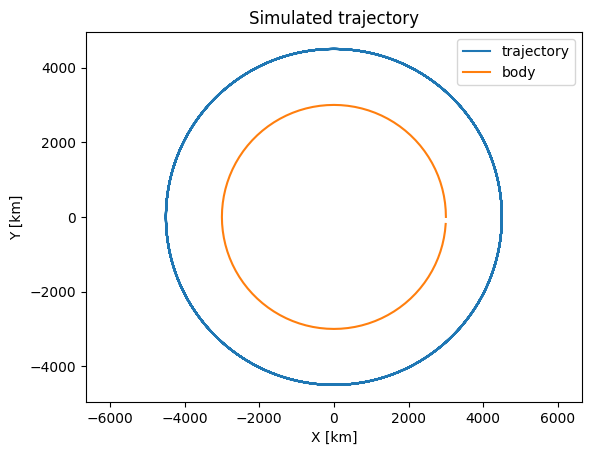

In [259]:
plt.title("Simulated trajectory")
plt.plot(op.states[:,0], op.states[:,1])
plt.plot(*circle_points(body["radius"], position=body["position"][0:2]))
plt.xlabel("X [km]")
plt.ylabel("Y [km]")
plt.legend(["trajectory", "body"])
plt.axis('equal')
plt.show()

## EKF on position measurements



In [260]:
# def simulate_camera_meas(r_p, )

def simulate_camera_meas(state: np.ndarray, R: np.ndarray, sigma_angle_perturb: float):
    """
    Simulate a camera measurement of a planet from a satellite.
    
    Parameters
    ----------
    state : np.ndarray, shape (3)
        Satellite state vector in planet frame (P->C).
    R : np.ndarray, shape (3,3)
        Measurement cov. matrix
    sigma_angle_perturb : float
        1-sigma measurement uncertainty of rotation matrix angular offset (for return value T_p_c)
    
    Returns
    -------
    r_c_meas : np.ndarray, shape (3,)
        Simulated measurement vector in camera frame (C->P), including noise.
    T_p_c : np.ndarray, shape (3,3)
        (TRUE) Rotation matrix from planet frame to camera frame.
    """
    
    rho_p = state[0:3]
    v_p = state[3:6]
    r_norm = np.linalg.norm(rho_p)
    r_c_unit = -rho_p / r_norm  # z-axis points toward planet (C->P)
    
    # ---------- Pick arbitrary x-axis perpendicular to z ----------

    x_cam = np.cross(rho_p, v_p)  # Cross with planet's z for equatorial x
    if np.linalg.norm(x_cam) < 1e-10:  # Degeneracy if r_c_unit is along z
        x_cam = np.cross([1, 0, 0], r_c_unit)  # Fallback to planet x

    x_cam /= norm(x_cam)
    y_cam = np.cross(r_c_unit, x_cam)
    
    # ---------- Define a rotation matrix T_p_c ----------
    T_p_c = np.column_stack((x_cam, y_cam, r_c_unit))  # rotates vector from planet->camera frame
    
        # ---------- Perturb T_p_c with angular uncertainty ----------
    # Generate a small random rotation axis and angle
    axis = np.random.normal(0, 1, 3)
    axis /= np.linalg.norm(axis)  # Unit axis
    angle = np.random.normal(0, sigma_angle_perturb)  # Perturbed angle
    # Apply Rodrigues' rotation for small angle approximation 
    # https://en.wikipedia.org/wiki/Rodrigues%27_rotation_formula#Matrix_notation
    K = np.array([[0, -axis[2], axis[1]],
                  [axis[2], 0, -axis[0]],
                  [-axis[1], axis[0], 0]])
    T_p_c_perturbed = T_p_c @ (np.eye(3) + np.sin(angle) * K + (1 - np.cos(angle)) * K @ K)
    
    # ---------- Transform true vector into camera frame with noise ----------
    r_c_true = T_p_c_perturbed @ rho_p  # P->C in camera frame
    
    # Noise yay
    r_c_meas = r_c_true + noise(R)
    
    return r_c_meas, T_p_c

In [261]:
# Q noise
factor = 100
sigma_a = 1e-2 * factor  # km/s^2
Q = np.block([
    [ (dt**3/3) * sigma_a**2 * np.eye(3), (dt**2/2) * sigma_a**2 * np.eye(3) ],
    [ (dt**2/2) * sigma_a**2 * np.eye(3), dt * sigma_a**2 * np.eye(3) ]
])

# R noise
factor = 1000
sigma_boresight = 10 * ARCSEC_TO_RAD * factor       
sigma_cross_boresight = 2 * ARCSEC_TO_RAD * factor

r_cp = norm(state0[0:3])  # example: 20,000 km distance approx, assuming it doesn't change

sigma_boresight_km = np.tan(sigma_boresight) * r_cp
sigma_cross_boresight_km    = np.tan(sigma_cross_boresight) * r_cp

R = np.diag([sigma_cross_boresight_km**2, sigma_cross_boresight_km**2, sigma_boresight_km**2])

In [269]:
mu0 = state0 + noise(Q) + np.array([100, 100, 1000, 0.1, 0.1, 0.1]) # Add some large initial error
Sigma0 = np.eye(6)
sigma_angle_perturb = 5*ARCSEC_TO_RAD

ekf = SatEKF(Q, R, dt, mu0, Sigma0, body["mass"])

measurement_frequency = 1_000 # steps

In [270]:
N = len(op.states)

mu_arr = np.zeros((N+1, 6))
Sigma_arr = np.zeros((N+1, 6, 6))
meas_arr = np.zeros((N+1, 3))
T_p_c_arr = np.zeros((N+1, 3, 3))
r_c_true_arr = np.zeros((N+1, 3))

mu_arr[0] = mu0
Sigma_arr[0] = Sigma0
meas_arr[0], T_p_c_arr[0] = simulate_camera_meas(state0, R, sigma_angle_perturb)
r_c_true_arr[0] = T_p_c_arr[0] @ mu0[0:3]



for i in range(N):
    # Simulate measurement
    rho_p = op.states[i, 0:3] - body["position"]  # P->C in planet frame
    r_c_meas, T_p_c_true = simulate_camera_meas(op.states[i], R, sigma_angle_perturb)
    
    # EKF update
    ekf.predict()

    if i % measurement_frequency == 0:
        print(f"Step {i}/{N} with measurement")
        ekf.update(r_c_meas, T_p_c_true)
    
    mu_arr[i+1] = ekf.mu
    Sigma_arr[i+1] = ekf.sigma
    meas_arr[i+1] = r_c_meas
    T_p_c_arr[i+1] = T_p_c_true
    r_c_true_arr[i+1] = -T_p_c_true @ rho_p

/Users/magi-nerv/Space-Specifically/Stanford/AA273/horizon-op-nav/utils.py:30: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  return np.random.multivariate_normal(


Step 0/94784 with measurement
Step 1000/94784 with measurement
Step 2000/94784 with measurement
Step 3000/94784 with measurement
Step 4000/94784 with measurement
Step 5000/94784 with measurement
Step 6000/94784 with measurement
Step 7000/94784 with measurement
Step 8000/94784 with measurement
Step 9000/94784 with measurement
Step 10000/94784 with measurement
Step 11000/94784 with measurement
Step 12000/94784 with measurement
Step 13000/94784 with measurement
Step 14000/94784 with measurement
Step 15000/94784 with measurement
Step 16000/94784 with measurement
Step 17000/94784 with measurement
Step 18000/94784 with measurement
Step 19000/94784 with measurement
Step 20000/94784 with measurement
Step 21000/94784 with measurement
Step 22000/94784 with measurement
Step 23000/94784 with measurement
Step 24000/94784 with measurement
Step 25000/94784 with measurement
Step 26000/94784 with measurement
Step 27000/94784 with measurement
Step 28000/94784 with measurement
Step 29000/94784 with measu

In [271]:
R = T_p_c_arr[0]
print(R @ np.array([1,0,0]).reshape((3,1)))
"""
[[1.95431921e-08]
 [0.00000000e+00]
 [1.00000000e+00]]
 """
print(R @ np.eye(3))
"""
[[ 1.95431921e-08 -3.94786777e-08 -1.00000000e+00]
 [ 0.00000000e+00  1.00000000e+00 -3.94786777e-08]
 [ 1.00000000e+00  7.71539380e-16  1.95431921e-08]]
 """
print()

[[0.]
 [0.]
 [1.]]
[[ 0.  0. -1.]
 [ 0.  1.  0.]
 [ 1.  0.  0.]]



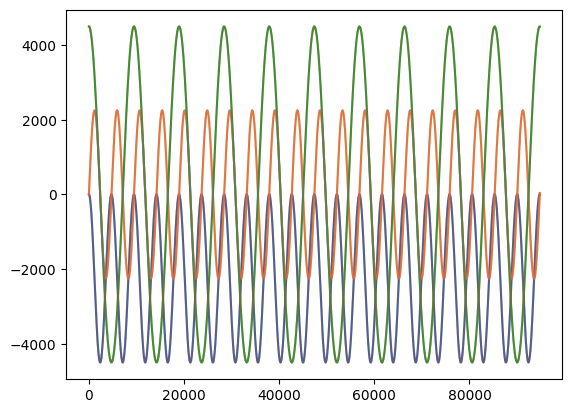

In [272]:
# plt.plot(-r_c_true_arr[1:,0], -r_c_true_arr[1:,2], label="True (noiseless) measurement")
plt.plot(-r_c_true_arr[1:], label="True (noiseless) measurement")
# plt.plot(meas_arr[:,0], meas_arr[:,2], label="True (noiseless) measurement")
plt.plot(meas_arr, label="True (noiseless) measurement", alpha = 0.3)
# plt.xlim = 

In [273]:
# plt.plot(ang_error[:,0])

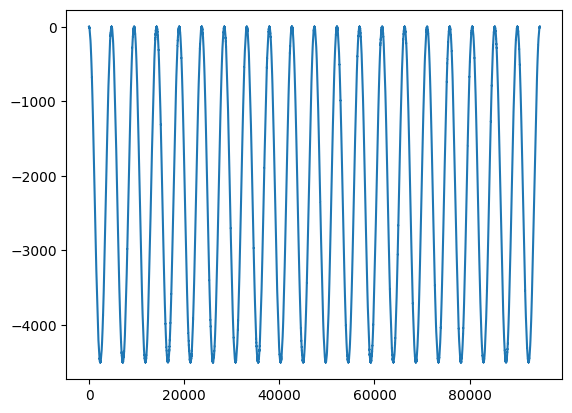

In [274]:
# print(meas_arr.shape)
plt.plot(meas_arr[:,0])

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


[4599.98378012 4153.88317222 3867.31175814 ... 4502.64766795 4502.63003094
 4502.61041893]


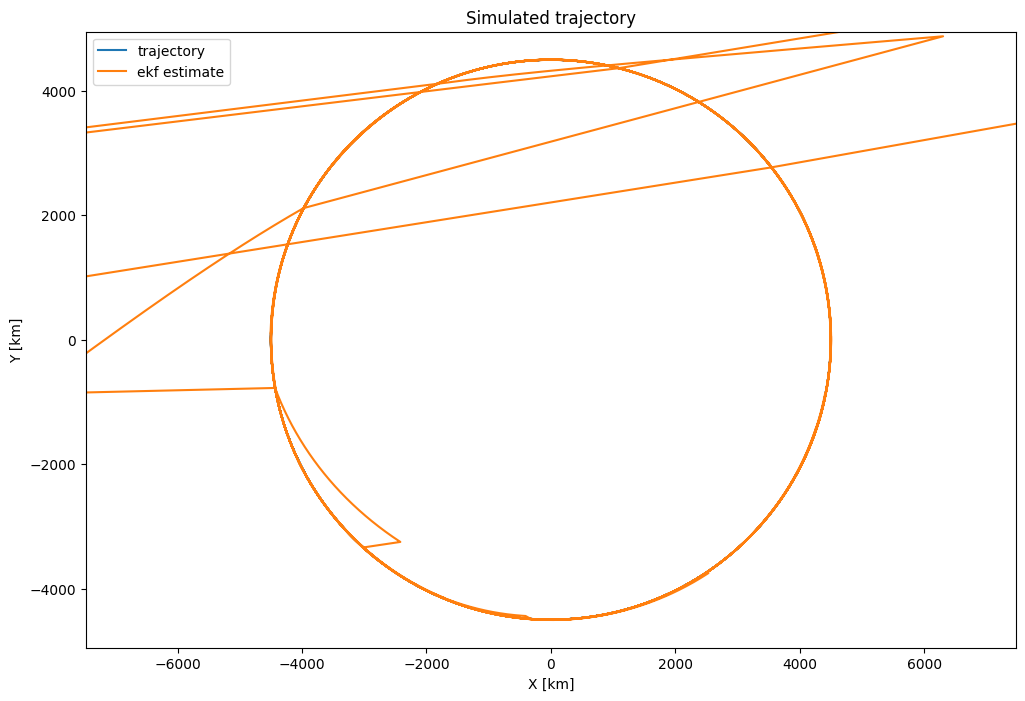

: 

In [ ]:
start_idx = 1000
stop_idx = -1

print(mu_arr[:stop_idx, 0])

# PLotting results
plt.figure(figsize=(12,8))
plt.title("Simulated trajectory")
plt.plot(op.states[start_idx:stop_idx,0], op.states[start_idx:stop_idx,1])
plt.plot(mu_arr[start_idx:stop_idx,0], mu_arr[start_idx:stop_idx,1])
# plt.plot(*circle_points(body["radius"], position=body["position"][0:2]))
plt.xlabel("X [km]")
plt.ylabel("Y [km]")
plt.legend(["trajectory", "ekf estimate"])
plt.axis('equal')

plt.xlim(op.states[start_idx:stop_idx,0].min() * 1.1, op.states[start_idx:stop_idx,0].max() * 1.1)
plt.ylim(op.states[start_idx:stop_idx,1].min() * 1.1, op.states[start_idx:stop_idx,1].max() * 1.1)
plt.show()

In [ ]:
plt.plot(op.states[:,0], label="True Trajectory")